# \# CreditWise 
## loan approval system

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")
df.head()
# df.isnull().sum()
# df.info()
# df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


## \# Handel missing values

In [3]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numarical_cols = df.select_dtypes(include=["number"]).columns

In [4]:
categorical_cols.size + numarical_cols.size

20

In [5]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = "mean")
df[numarical_cols] = num_imp.fit_transform(df[numarical_cols])

In [6]:
cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [7]:
# remove applicat id
df = df.drop("Applicant_ID", axis=1)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# \# EDA - exploratory data analysis

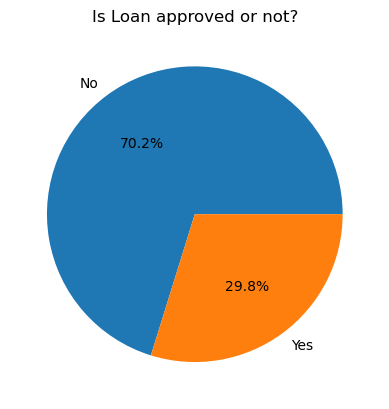

In [8]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not?")
plt.show()

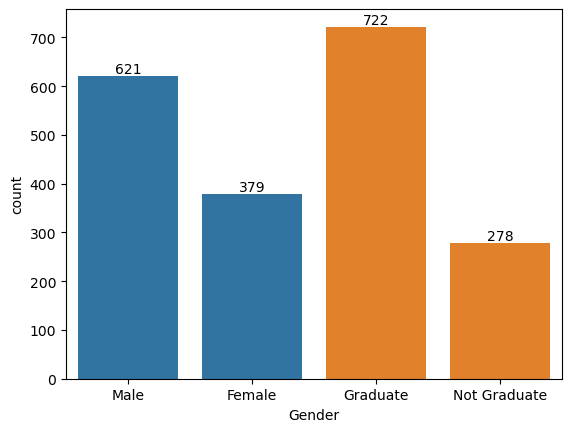

In [9]:
# analize categories

gender_count = df["Gender"].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

edu_count = df["Education_Level"].value_counts()
ax = sns.barplot(edu_count)
ax.bar_label(ax.containers[1])

plt.show()


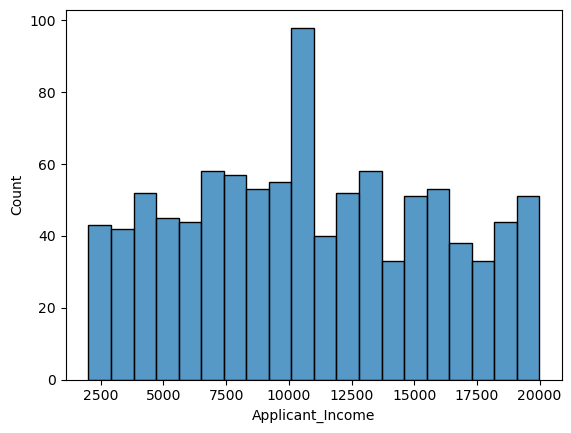

In [10]:
# analize income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)
plt.show()

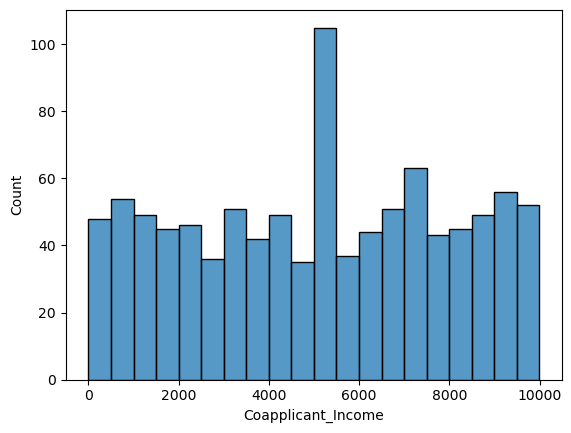

In [11]:
# analize income

sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)
plt.show()

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

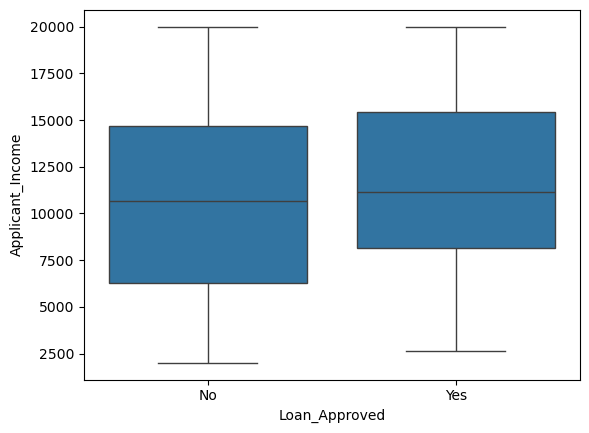

In [12]:
# outliers -> boxplot
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

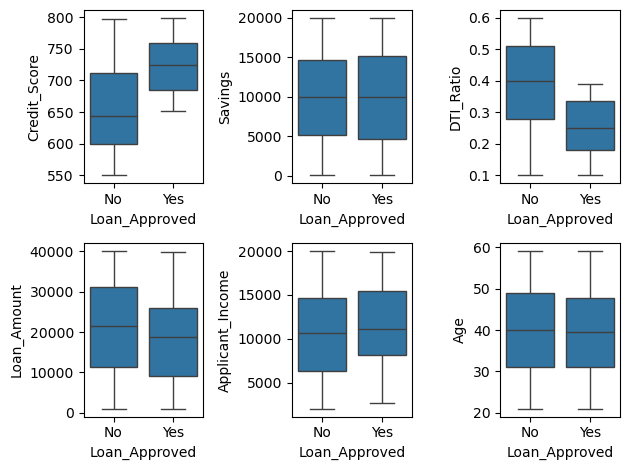

In [13]:
fig, ax = plt.subplots(2,3)

sns.boxplot(ax = ax[0,0], data = df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = ax[0,1], data = df,x = "Loan_Approved",y = "Savings")
sns.boxplot(ax = ax[0,2], data = df,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = ax[1,0], data = df,x = "Loan_Approved",y = "Loan_Amount")
sns.boxplot(ax = ax[1,1], data = df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = ax[1,2], data = df,x = "Loan_Approved",y = "Age")


fig.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

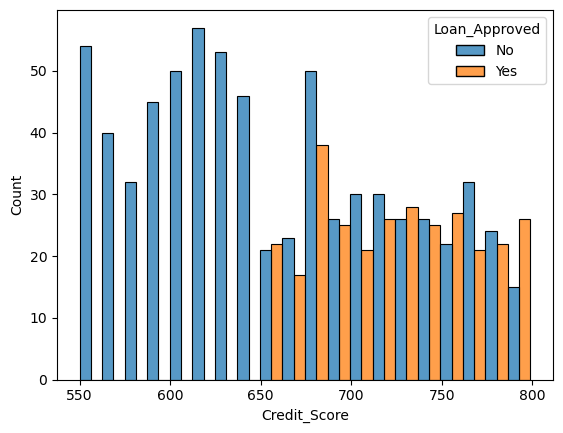

In [14]:
# relation with creadit score with loan approved

sns.histplot(
    data = df,
    x = "Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

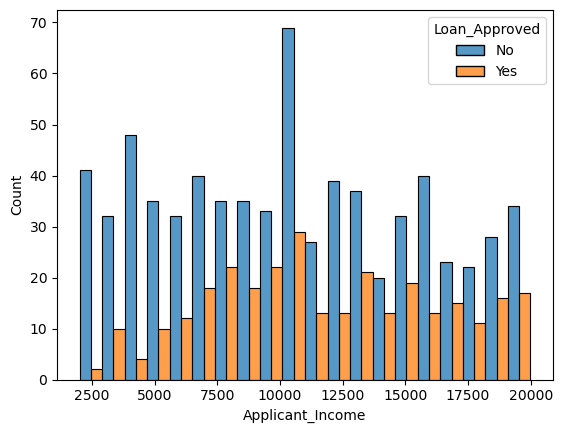

In [15]:

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

# \# Feature Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [17]:
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [18]:
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

onehot = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = onehot.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=onehot.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [19]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


 # \# correlaiton heatmap

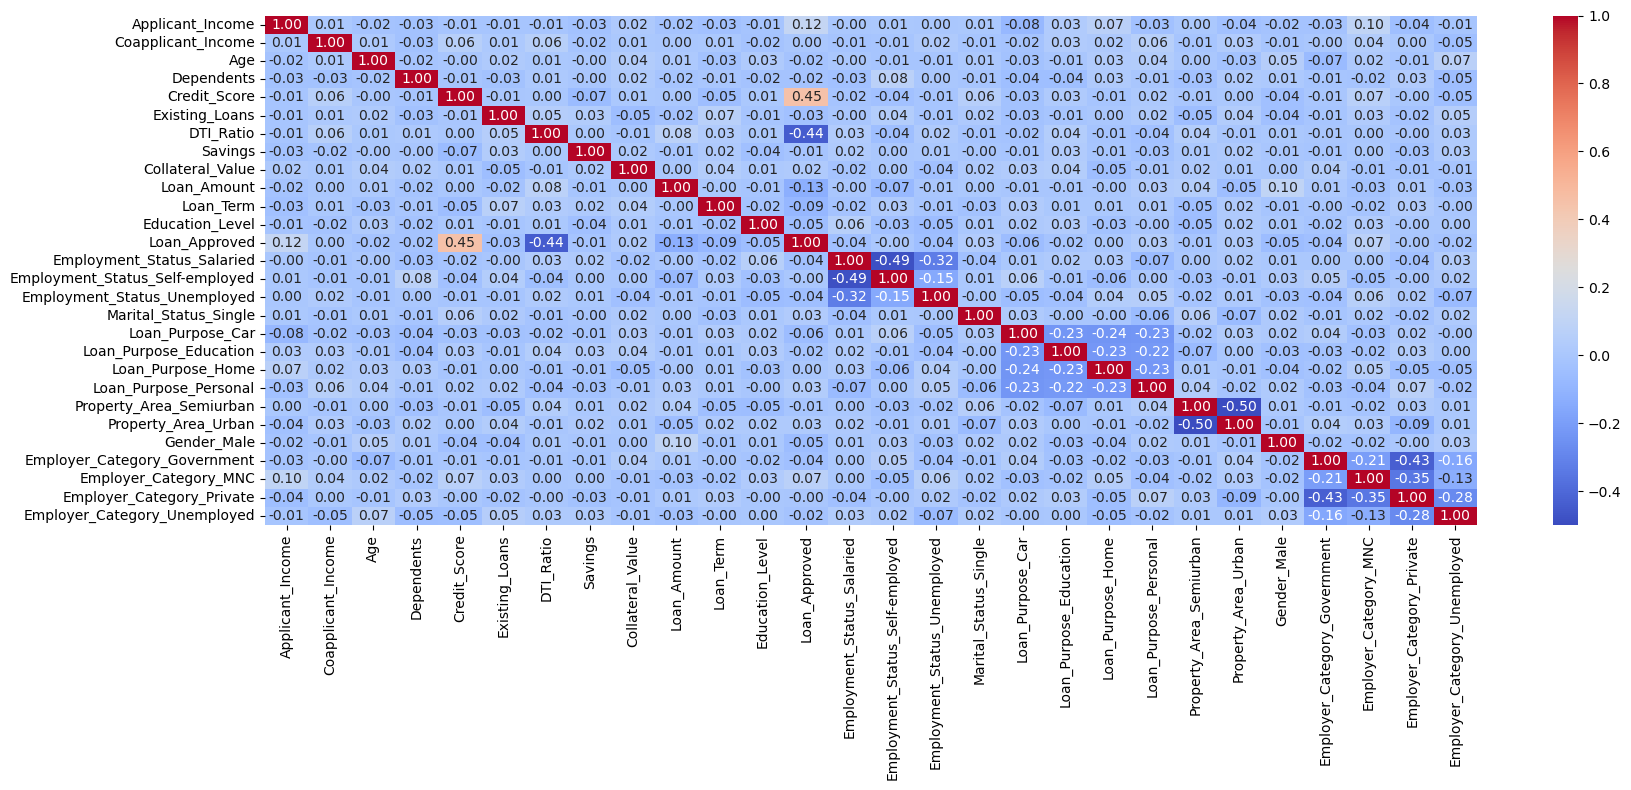

In [20]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()
# num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

plt.figure(figsize=(18,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap="coolwarm"
)
plt.tight_layout()
plt.show()

# \# Train Test Split + Feature scaling

In [21]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [23]:
# featrue scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and Evaluate our Model

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# \->> Logistic Regression Model

In [25]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# \->> KNN Model

In [26]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# \->> Naive Bayes Model

In [27]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [28]:
models = {"Logistic Regression":lr_model, "KNN":knn_model, "Naive Bayes":nb_model}

for name, model in models.items():
    print("\n\n#",name,"\n")

    y_pred = model.predict(X_test_scaled)

    print("Accuracy : ", accuracy_score(y_test,y_pred))
    print("Precision : ", precision_score(y_test,y_pred))
    print("Recall : ", recall_score(y_test,y_pred))
    # print("f1_score : ", f1_score(y_test,y_pred))
    # print("confusion matrix : \n", confusion_matrix(y_test,y_pred))

# best model -> Naive Bayes



# Logistic Regression 

Accuracy :  0.865
Precision :  0.7833333333333333
Recall :  0.7704918032786885


# KNN 

Accuracy :  0.76
Precision :  0.6274509803921569
Recall :  0.5245901639344263


# Naive Bayes 

Accuracy :  0.865
Precision :  0.8035714285714286
Recall :  0.7377049180327869


# Best Model on the Basis of Precision => Naive Bayes

# \# feature Engineering

In [29]:
# # add or transform data
# # if we do so this it give 1 for lr and naive bayes
# df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
# df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"]) # skewed


# X = df.drop(columns = ["Credit_Score","DTI_Ratio","Applicant_Income"])
# y = df["Loan_Approved"]

In [36]:
# add or transform data
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"]) # skewed

X = df.drop(columns = ["Loan_Approved","Credit_Score","DTI_Ratio"])
y = df["Loan_Approved"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
# featrue scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [40]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [41]:
models = {"Logistic Regression":lr_model, "KNN":knn_model, "Naive Bayes":nb_model}

for name, model in models.items():
    print("\n\n#",name,"\n")

    y_pred = model.predict(X_test_scaled)

    print("Accuracy : ", accuracy_score(y_test,y_pred))
    print("Precision : ", precision_score(y_test,y_pred))
    print("Recall : ", recall_score(y_test,y_pred))
    # print("f1_score : ", f1_score(y_test,y_pred))
    # print("confusion matrix : \n", confusion_matrix(y_test,y_pred))





# Logistic Regression 

Accuracy :  0.88
Precision :  0.7846153846153846
Recall :  0.8360655737704918


# KNN 

Accuracy :  0.785
Precision :  0.6730769230769231
Recall :  0.5737704918032787


# Naive Bayes 

Accuracy :  0.86
Precision :  0.8113207547169812
Recall :  0.7049180327868853


# => after feature engineering logitic regression inhanced overall
# but best model is naive model in second Logistic Regression